In [3]:
import srfm
import srfm.main
import inspect
import importlib.metadata
import numpy as np
import matplotlib.pyplot as plt
"""If running the SRFM with a driver table, run this code."""
from srfm import *
import xarray as xr
from scipy.interpolate import interp1d
import os
import pandas as pd
import iris
import iris.quickplot as qplt
from scipy.optimize import least_squares

/home/m/moulin-garrigues/miniforge3/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [ ]:
#Profile 0 - across all 8 combinations

# Comparing Ash datasets RTTOV vs SRFM

## All Channels, all Profiles - comparison by Channel

Statistics

Channel 07
  Number of points = 80
  Mean Bias        = 0.001294
  RMSE             = 0.005234
  Standard Deviation = 0.005071

Channel 09
  Number of points = 80
  Mean Bias        = -0.000158
  RMSE             = 0.006823
  Standard Deviation = 0.006821

Channel 10
  Number of points = 80
  Mean Bias        = -0.001845
  RMSE             = 0.008573
  Standard Deviation = 0.008372

Channel 11
  Number of points = 80
  Mean Bias        = 0.002779
  RMSE             = 0.006809
  Standard Deviation = 0.006216


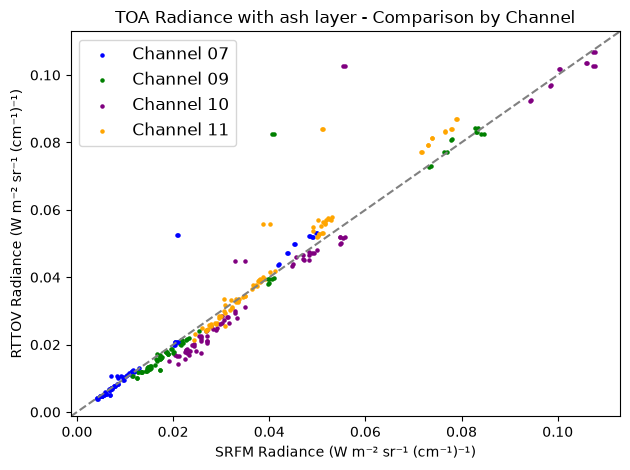

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

channels = [7, 9, 10, 11]

colors = {
    7: "blue",
    9: "green",
    10: "purple",
    11: "orange"
}

# Store differences separately for each channel
all_diff = {ch: [] for ch in channels}


for profile in range(10):

    Data = (
        f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/"
        f"Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"
    )

    df = pd.read_csv(Data)

    for ch in channels:

        # -----------------------------
        # Get the data for this channel
        # -----------------------------
        srfm = df[f"ch{ch:02d}"]
        rttov = df[f"RTTOV_ch{ch:02d}"] * 1e-3

        # -----------------------------
        # Scatter plot
        # -----------------------------
        ax.scatter(
            srfm,
            rttov,
            color=colors[ch],
            s=5,
            label=f"Channel {ch:02d}" if profile == 0 else None,
        )

        # -----------------------------
        # Difference RTTOV - SRFM
        # -----------------------------
        diff = (rttov - srfm).dropna().values

        # Store differences for THIS channel
        all_diff[ch].extend(diff)



# ============================================================

lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1])
]

ax.plot(
    lims,
    lims,
    color="gray",
    linestyle="--"
)

ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("SRFM Radiance (W m⁻² sr⁻¹ (cm⁻¹)⁻¹)")
ax.set_ylabel("RTTOV Radiance (W m⁻² sr⁻¹ (cm⁻¹)⁻¹)")

ax.set_title(
    "TOA Radiance with ash layer - Comparison by Channel"
)

ax.legend(fontsize=12)

plt.tight_layout()

plt.savefig(
    "/home/m/moulin-garrigues/SRFM_RTTOV/Report_Figures/ash_channel.png",
    dpi=300
)


# STATISTICS
# ============================================================

print("Statistics")
print("=" * 60)

for ch in channels:

    diff = np.asarray(all_diff[ch])

    mean_bias = np.mean(diff)
    rmse = np.sqrt(np.mean(diff ** 2))
    stdev = np.std(diff)

    print(f"\nChannel {ch:02d}")
    print(f"  Number of points = {len(diff)}")
    print(f"  Mean Bias        = {mean_bias:.6f}")
    print(f"  RMSE             = {rmse:.6f}")
    print(f"  Standard Deviation = {stdev:.6f}")


plt.show()


Profile 7, Channel 7
SRFM:
[0.020388 0.020358 0.006705 0.006555 0.005205 0.005052 0.005154 0.005007]
RTTOV:
[0.0208033  0.02078432 0.0067514  0.00667107 0.00478228 0.00471907
 0.00474659 0.00469353]
Difference:
[ 4.15303356e-04  4.26320884e-04  4.64008319e-05  1.16068662e-04
 -4.22721817e-04 -3.32931140e-04 -4.07410933e-04 -3.13469808e-04]


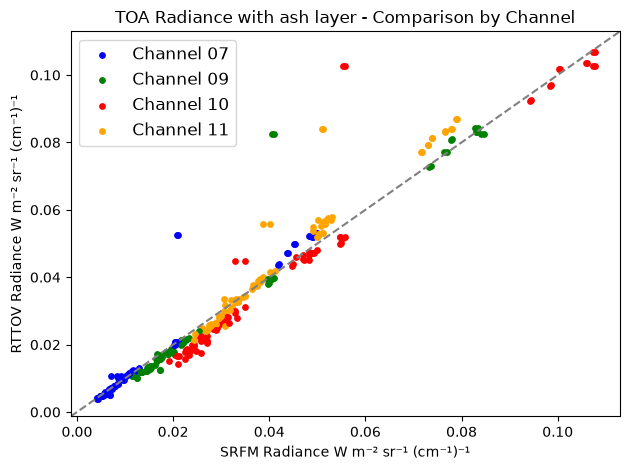

Statistics
----------------------------------------
Channel 07
  Mean Bias = 1.2936035934e-03
  RMSE      = 5.2335929652e-03
  Standard Deviation of difference = 5.0712015409e-03
Channel 09
  Mean Bias = -1.5796659864e-04
  RMSE      = 6.8231858671e-03
  Standard Deviation of difference = 6.8213570447e-03
Channel 10
  Mean Bias = -1.8445369817e-03
  RMSE      = 8.5726684904e-03
  Standard Deviation of difference = 8.3718772309e-03
Channel 11
  Mean Bias = 2.7786840164e-03
  RMSE      = 6.8089210020e-03
  Standard Deviation of difference = 6.2161338747e-03


In [ ]:
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]

colors = {
    7: "blue",
    9: "green",
    10: "red",
    11: "orange"
}

all_diff = {ch: [] for ch in channels}

for profile in range(10):

    Data = (
        f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/"
        f"Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"
    )

    df = pd.read_csv(Data)

    for ch in channels:

        srfm = df[f"ch{ch:02d}"]
        rttov = df[f"RTTOV_ch{ch:02d}"] * 1e-3

        ax.scatter(
            srfm,
            rttov,
            color=colors[ch],
            s=15,
            label=f"Channel {ch:02d}" if profile == 0 else None,
        )

        # Difference for statistics
        diff = (rttov - srfm).values
        all_diff[ch].extend(diff)

        # Optional check
        if profile == 7 and ch == 7:
            print("Profile 7, Channel 7")
            print("SRFM:")
            print(srfm.values)
            print("RTTOV:")
            print(rttov.values)
            print("Difference:")
            print(diff)


# x = y
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]

ax.plot(
    lims,
    lims,
    color="gray",
    linestyle="--"
)

ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("SRFM Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_ylabel("RTTOV Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_title("TOA Radiance with ash layer - Comparison by Channel")
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


# STATISTICS
# ==========================================================

print("Statistics")
print("-" * 40)

for ch in channels:

    diff = np.array(all_diff[ch])

    mean_bias = diff.mean()
    rmse = np.sqrt(np.mean(diff**2))
    stdev = np.std(diff)

    print(f"Channel {ch:02d}")
    print(f"  Mean Bias = {mean_bias:.10e}")
    print(f"  RMSE      = {rmse:.10e}")
    print(f"  Standard Deviation of difference = {stdev:.10e}")


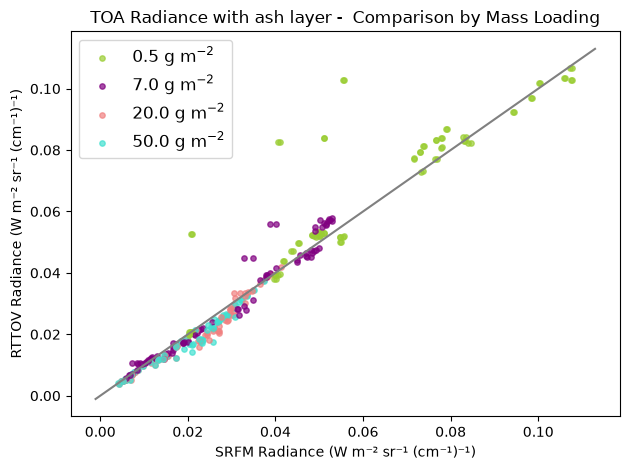

In [54]:
##Color according to Mass Loading

fig, ax = plt.subplots()

channels = [7, 9, 10, 11]

# Colour = mass loading
mass_colors = {
    0.5: "yellowgreen",
    7.0: "purple",
    20.0: "lightcoral",
    50.0: "turquoise",
}

mass_loadings = [0.5, 7.0, 20.0, 50.0]

for profile in range(10):

    Data = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"


    df = pd.read_csv(Data)

    for ch in channels:

        for ml in mass_loadings:

            group = df[df["mass_loading"] == ml]

            srfm = group[f"ch{ch:02d}"]
            rttov = group[f"RTTOV_ch{ch:02d}"] * 1e-3

            ax.scatter(
                srfm,
                rttov,
                color=mass_colors[ml],
                s=15,
                alpha=0.7,
                label=(
                    f"{ml} g m$^{{-2}}$"
                    if profile == 0 and ch == 7
                    else None
                )
            )

lims = ax.get_xlim()
ax.plot(lims, lims, color="gray")

ax.set_xlabel("SRFM Radiance (W m⁻² sr⁻¹ (cm⁻¹)⁻¹)")
ax.set_ylabel("RTTOV Radiance (W m⁻² sr⁻¹ (cm⁻¹)⁻¹)")
ax.set_title("TOA Radiance with ash layer -  Comparison by Mass Loading")
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig("/home/m/moulin-garrigues/SRFM_RTTOV/Report_Figures/ash_ml.png")
plt.show()




Mass loading = 0.5 g m^-2
 mass_loading     ch07  RTTOV_ch07
          0.5 0.048431   52.289307
          0.5 0.048356   51.926195

Mass loading = 7.0 g m^-2
 mass_loading     ch07  RTTOV_ch07
          7.0 0.011753   12.457096
          7.0 0.011318   11.434004

Mass loading = 20.0 g m^-2
 mass_loading     ch07  RTTOV_ch07
         20.0 0.007837    7.798719
         20.0 0.007317    7.028884

Mass loading = 50.0 g m^-2
 mass_loading     ch07  RTTOV_ch07
         50.0 0.007741    7.764858
         50.0 0.007197    6.989938


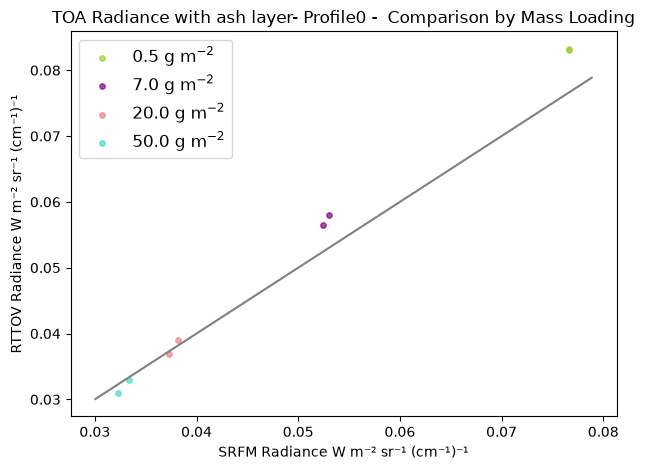

In [9]:
##Color according to Mass Loading

fig, ax = plt.subplots()

channels = [7, 9, 10, 11]

# Colour = mass loading
mass_colors = {
    0.5: "yellowgreen",
    7.0: "purple",
    20.0: "lightcoral",
    50.0: "turquoise",
}

mass_loadings = [0.5, 7.0, 20.0, 50.0]

profile = 0
Data = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"

df = pd.read_csv(Data)

ch = 11

for ml in mass_loadings:

    # Select the current mass loading FIRST
    group = df[df["mass_loading"] == ml]

    print(f"\nMass loading = {ml} g m^-2")
    print(
        group[
            ["mass_loading", "ch07", "RTTOV_ch07"]
        ].to_string(index=False)
    )

    srfm = group[f"ch{ch:02d}"]
    rttov = group[f"RTTOV_ch{ch:02d}"] * 1e-3

    ax.scatter(
        srfm,
        rttov,
        color=mass_colors[ml],
        s=15,
        alpha=0.7,
        label=f"{ml} g m$^{{-2}}$"
    )
   

lims = ax.get_xlim()
ax.plot(lims, lims, color="gray")

ax.set_xlabel("SRFM Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_ylabel("RTTOV Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_title("TOA Radiance with ash layer- Profile0 -  Comparison by Mass Loading")
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

Mass loadings actually in CSV:
[ 0.5  7.  20.  50. ]

Mass loading = 0.5 from CSV
 mass_loading     ch07  RTTOV_ch07
          0.5 0.048431   52.289307
          0.5 0.048356   51.926195

Mass loading = 7.0 from CSV
 mass_loading     ch07  RTTOV_ch07
          7.0 0.011753   12.457096
          7.0 0.011318   11.434004

Mass loading = 20.0 from CSV
 mass_loading     ch07  RTTOV_ch07
         20.0 0.007837    7.798719
         20.0 0.007317    7.028884

Mass loading = 50.0 from CSV
 mass_loading     ch07  RTTOV_ch07
         50.0 0.007741    7.764858
         50.0 0.007197    6.989938


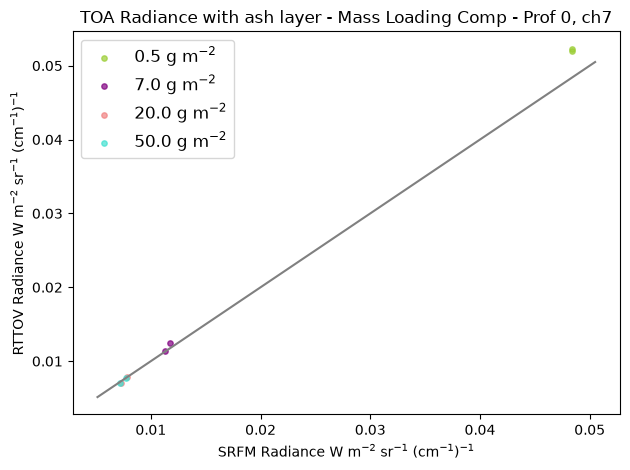

In [10]:

fig, ax = plt.subplots()

channels = [7, 9, 10, 11]

mass_colors = {
    0.5: "yellowgreen",
    7.0: "purple",
    20.0: "lightcoral",
    50.0: "turquoise",
}

mass_loadings = [0.5, 7.0, 20.0, 50.0]

profile = 0

Data = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"

df = pd.read_csv(Data)

print("Mass loadings actually in CSV:")
print(df["mass_loading"].unique())

ch = 7

for ml in mass_loadings:

    # Select rows where CSV mass_loading == ml
    group = df[np.isclose(df["mass_loading"], ml)]

    print(f"\nMass loading = {ml} from CSV")
    print(
        group[
            ["mass_loading", f"ch{ch:02d}", f"RTTOV_ch{ch:02d}"]
        ].to_string(index=False)
    )

    srfm = group[f"ch{ch:02d}"]
    rttov = group[f"RTTOV_ch{ch:02d}"] * 1e-3

    ax.scatter(
        srfm,
        rttov,
        color=mass_colors[ml],
        s=15,
        alpha=0.7,
        label=f"{ml} g m$^{{-2}}$"
    )

lims = ax.get_xlim()
ax.plot(lims, lims, color="gray")

ax.set_xlabel(
    "SRFM Radiance W m$^{-2}$ sr$^{-1}$ (cm$^{-1}$)$^{-1}$"
)

ax.set_ylabel(
    "RTTOV Radiance W m$^{-2}$ sr$^{-1}$ (cm$^{-1}$)$^{-1}$"
)

ax.set_title(
    "TOA Radiance with ash layer"
     " - Mass Loading Comp - Prof 0, ch7"
)

ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:

# Colour = mass loading
mass_colors = {
    0.5: "blue",
    7.0: "green",
    20.0: "orange",
    50.0: "red",
}

mass_loadings = [0.5, 7.0, 20.0, 50.0]

for profile in range(10):

    Data = (
        f"/home/m/moulin-garrigues/RTTOV/Full_Rad_7_08/"
        f"Merge_Ash_numdem/Merge_{profile}_numdem.csv"
    )

    df = pd.read_csv(Data)

    for ch in channels:

        for ml in mass_loadings:

            group = df[df["mass_loading"] == ml]

            srfm = group[f"ch{ch:02d}"]
            rttov = group[f"RTTOV_ch{ch:02d}"] * 1e-3

            fraction = ((rttov - srfm) / srfm) * 100

            ax.scatter(
                srfm,
                fraction,
                color=mass_colors[ml],
                s=15,
                alpha=0.7,
                label=(
                    f"{ml} g m$^{{-2}}$"
                    if profile == 0 and ch == 7
                    else None
                )
            )


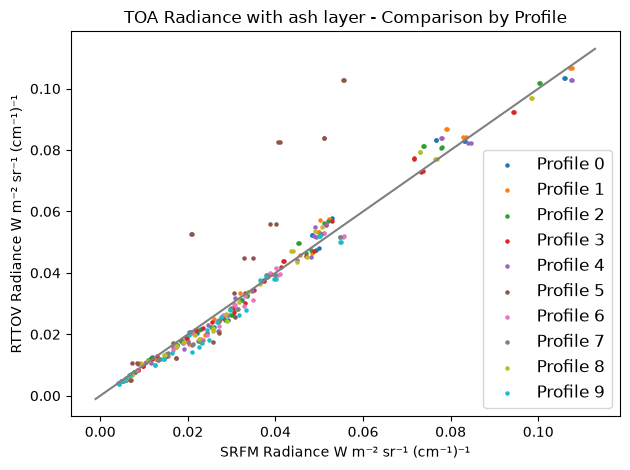

In [55]:
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]

profile_colors = plt.cm.tab10(range(10))

for profile in range(10):
    Data = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"
    df = pd.read_csv(Data)
    for ch in channels:
        ax.scatter(
            df[f"ch{ch:02d}"],
            df[f"RTTOV_ch{ch:02d}"] * 1e-3,

            s=5,
            color=profile_colors[profile],
            label=f"Profile {profile}" if ch == 7 else None
            
        )

lims = ax.get_xlim()
ax.plot(lims, lims, color="gray")

ax.set_xlabel("SRFM Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_ylabel("RTTOV Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_title("TOA Radiance with ash layer - Comparison by Profile")
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

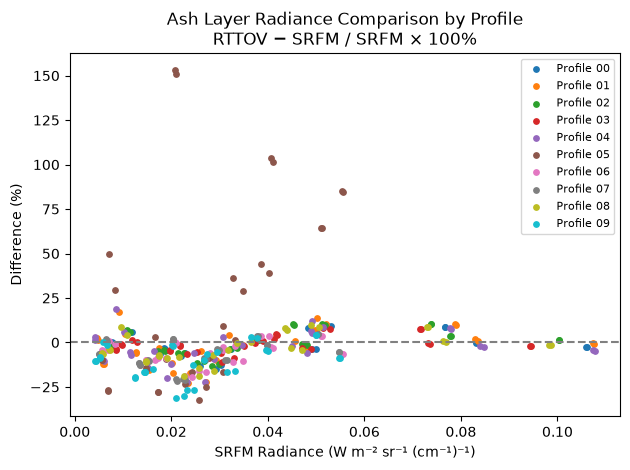

Percentage Bias Statistics
--------------------------------------------------
Channel 07
  Mean percentage bias = 4.0054%
Channel 09
  Mean percentage bias = -4.7763%
Channel 10
  Mean percentage bias = -8.3124%
Channel 11
  Mean percentage bias = 4.3535%


In [91]:
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]

profile_colors = plt.cm.tab10(range(10))

all_percent_diff = {ch: [] for ch in channels}

for profile in range(10):

    Data = (
        f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/"
        f"Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"
    )

    df = pd.read_csv(Data)

    for ch in channels:

        srfm = df[f"ch{ch:02d}"]
        rttov = df[f"RTTOV_ch{ch:02d}"] * 1e-3

        # Percentage difference
        fraction = ((rttov - srfm) / srfm) * 100

        # Save percentage differences for statistics
        all_percent_diff[ch].extend(fraction.values)


        # Plot
        ax.scatter(
            srfm,
            fraction,
            color=profile_colors[profile],
            s=15,
            label=f"Profile {profile:02d}" if ch == 7 else None
        )


ax.axhline(
    0,
    color="gray",
    linestyle="--"
)

ax.set_xlabel(
    "SRFM Radiance (W m⁻² sr⁻¹ (cm⁻¹)⁻¹)"
)

ax.set_ylabel(
    "Difference (%)"
)

ax.set_title(
    "Ash Layer Radiance Comparison by Profile\n"
    "RTTOV − SRFM / SRFM × 100%"
)

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# STATISTICS
# ============================================================

print("Percentage Bias Statistics")
print("-" * 50)

for ch in channels:

    #percent_diff = np.asarray(all_percent_diff[ch])

    mean_bias = np.mean(percent_diff)

    print(f"Channel {ch:02d}")
    print(f"  Mean percentage bias = {mean_bias:.4f}%")


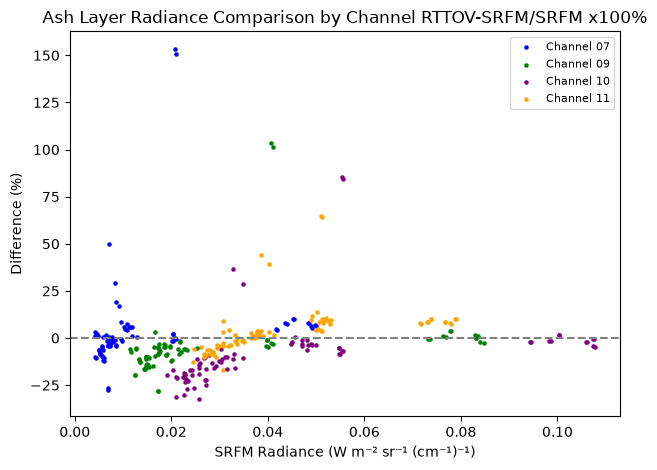

In [71]:
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]
colors = {
    7: "blue",
    9: "green",
    10: "purple",
    11: "orange"
}


profile_colors = plt.cm.tab10(range(10))  # 10 different colors for profiles 0-9

for profile in range(10):

    Data = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"
    df = pd.read_csv(Data)

    for ch in channels:
        srfm = df[f"ch{ch:02d}"]
        rttov = df[f"RTTOV_ch{ch:02d}"] * 1e-3
        fraction = ((rttov - srfm)/srfm) *100
        ax.scatter(srfm, fraction, color = colors[ch],
        s=5,
        label=f"Channel {ch:02d}" if profile == 0 else None)

ax.axhline(0, color="gray", linestyle="--")
ax.set_xlabel("SRFM Radiance (W m⁻² sr⁻¹ (cm⁻¹)⁻¹)")
ax.set_ylabel("Difference (%)")
ax.set_title("Ash Layer Radiance Comparison by Channel RTTOV-SRFM/SRFM x100%")

ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("/home/m/moulin-garrigues/SRFM_RTTOV/Report_Figures/ash_ml.png")

plt.show()

## Difference vs Property: MASS LOADING

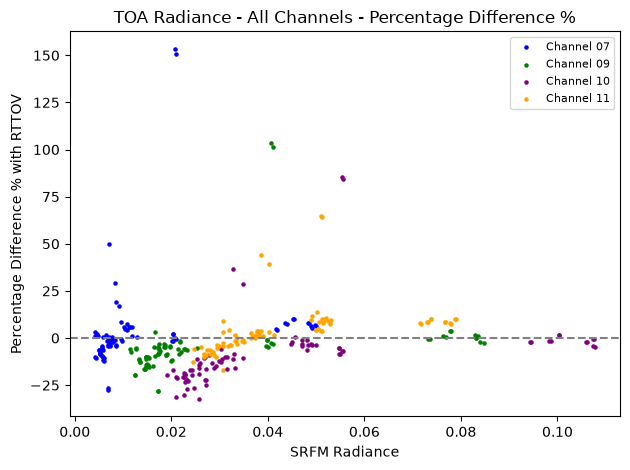

In [58]:
fig, ax = plt.subplots()

ch = 7
colors = {
    7: "blue",
    9: "green",
    10: "purple",
    11: "orange"
}

profile_colors = plt.cm.tab10(range(10))  # 10 different colors for profiles 0-9

for profile in range(10):

    Data = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"
    df = pd.read_csv(Data)

    for ch in channels:
        srfm = df[f"ch{ch:02d}"]
        rttov = df[f"RTTOV_ch{ch:02d}"] * 1e-3
        fraction = ((rttov - srfm)/srfm) *100
        ax.scatter(srfm, fraction, color = colors[ch],
        s=5,
        label=f"Channel {ch:02d}" if profile == 0 else None)

ax.axhline(0, color="gray", linestyle="--")
ax.set_xlabel("SRFM Radiance")
ax.set_ylabel("Percentage Difference % with RTTOV")
ax.set_title("TOA Radiance - All Channels - Percentage Difference %")

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

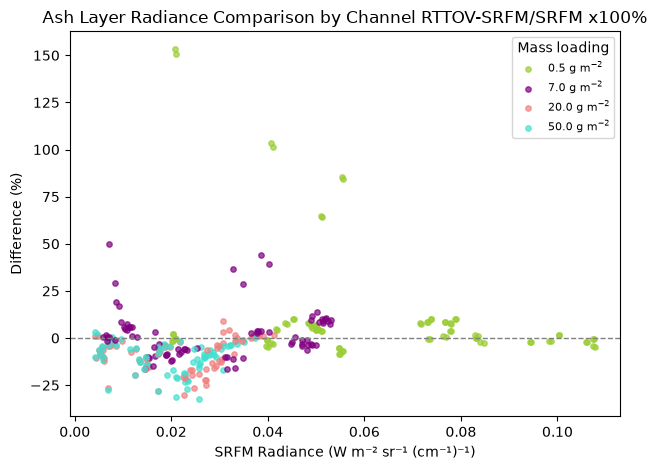

In [72]:
##Color according to Mass Loading

fig, ax = plt.subplots()

channels = [7, 9, 10, 11]

# Colour = mass loading
mass_colors = {
    0.5: "yellowgreen",
    7.0: "purple",
    20.0: "lightcoral",
    50.0: "turquoise",
}

mass_loadings = [0.5, 7.0, 20.0, 50.0]

for profile in range(10):

    Data = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"


    df = pd.read_csv(Data)

    for ch in channels:

        for ml in mass_loadings:

            group = df[df["mass_loading"] == ml]

            srfm = group[f"ch{ch:02d}"]
            rttov = group[f"RTTOV_ch{ch:02d}"] * 1e-3

            fraction = ((rttov - srfm) / srfm) * 100

            ax.scatter(
                srfm,
                fraction,
                color=mass_colors[ml],
                s=15,
                alpha=0.7,
                label=(
                    f"{ml} g m$^{{-2}}$"
                    if profile == 0 and ch == 7
                    else None
                )
            )

ax.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1
)

ax.set_xlabel("SRFM Radiance (W m⁻² sr⁻¹ (cm⁻¹)⁻¹)")
ax.set_ylabel("Difference (%)")
ax.set_title("Ash Layer Radiance Comparison by Channel RTTOV-SRFM/SRFM x100%")

ax.legend(
    title="Mass loading",
    fontsize=8
)

plt.tight_layout()
plt.savefig("/home/m/moulin-garrigues/SRFM_RTTOV/Report_Figures/ash_ml_%.png")
plt.show()

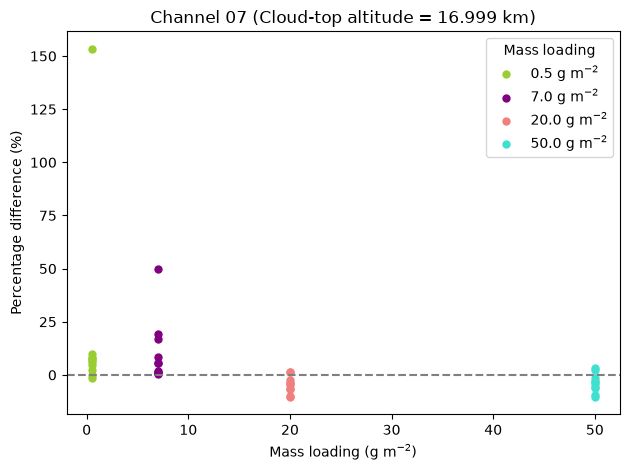

In [60]:
fig, ax = plt.subplots()

ch = 7

# Fixed cloud-top altitude
alt_upp = 16.999

# One color per mass loading
mass_colors = {
    0.5: "yellowgreen",
    7.0: "purple",
    20.0: "lightcoral",
    50.0: "turquoise",
}

for profile in range(10):

    Data = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"

    df = pd.read_csv(Data)

    # Keep all mass loadings at this altitude
    df = df[np.isclose(df["alt_upp"], alt_upp)]

    for ml, group in df.groupby("mass_loading"):

        srfm = group[f"ch{ch:02d}"]
        rttov = group[f"RTTOV_ch{ch:02d}"] * 1e-3
        fraction = (rttov - srfm) / srfm * 100

        ax.scatter(
            group["mass_loading"],
            fraction,
            color=mass_colors[ml],
            s=25,
            label=f"{ml} g m$^{{-2}}$" if profile == 0 else None,
        )

ax.axhline(0, color="gray", linestyle="--")

ax.set_xlabel("Mass loading (g m$^{-2}$)")
ax.set_ylabel("Percentage difference (%)")
ax.set_title(f"Channel {ch:02d} (Cloud-top altitude = {alt_upp} km)")
ax.legend(title="Mass loading")

plt.tight_layout()
plt.show()

### Difference vs Property: MASS LOADING - difference vs mass loading for channel n, all profiles

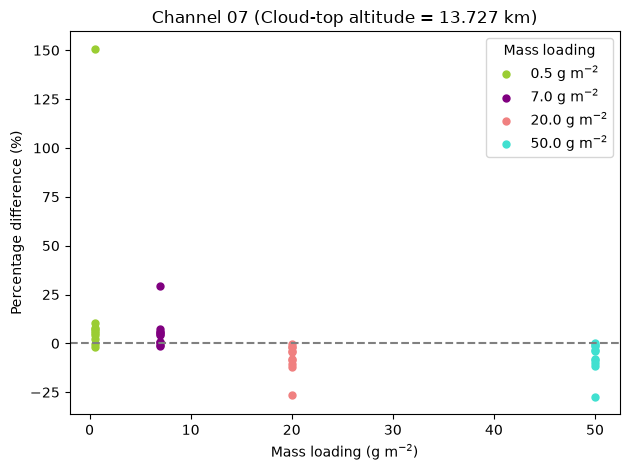

In [61]:
fig, ax = plt.subplots()

ch = 7

# Fixed cloud-top altitude
alt_upp = 13.727

# One color per mass loading
mass_colors = {
    0.5: "yellowgreen",
    7.0: "purple",
    20.0: "lightcoral",
    50.0: "turquoise",
}

for profile in range(10):

    Data = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"

    df = pd.read_csv(Data)

    # Keep all mass loadings at this altitude
    df = df[np.isclose(df["alt_upp"], alt_upp)]

    for ml, group in df.groupby("mass_loading"):

        srfm = group[f"ch{ch:02d}"]
        rttov = group[f"RTTOV_ch{ch:02d}"] * 1e-3
        fraction = (rttov - srfm) / srfm * 100

        ax.scatter(
            group["mass_loading"],
            fraction,
            color=mass_colors[ml],
            s=25,
            label=f"{ml} g m$^{{-2}}$" if profile == 0 else None,
        )

ax.axhline(0, color="gray", linestyle="--")

ax.set_xlabel("Mass loading (g m$^{-2}$)")
ax.set_ylabel("Percentage difference (%)")
ax.set_title(f"Channel {ch:02d} (Cloud-top altitude = {alt_upp} km)")
ax.legend(title="Mass loading")

plt.tight_layout()
plt.show()

Profile 0, Channel 7, mass loadings = [np.float64(0.5), np.float64(7.0), np.float64(20.0), np.float64(50.0)]
Profile 0, Channel 9, mass loadings = [np.float64(0.5), np.float64(7.0), np.float64(20.0), np.float64(50.0)]
Profile 0, Channel 10, mass loadings = [np.float64(0.5), np.float64(7.0), np.float64(20.0), np.float64(50.0)]
Profile 0, Channel 11, mass loadings = [np.float64(0.5), np.float64(7.0), np.float64(20.0), np.float64(50.0)]


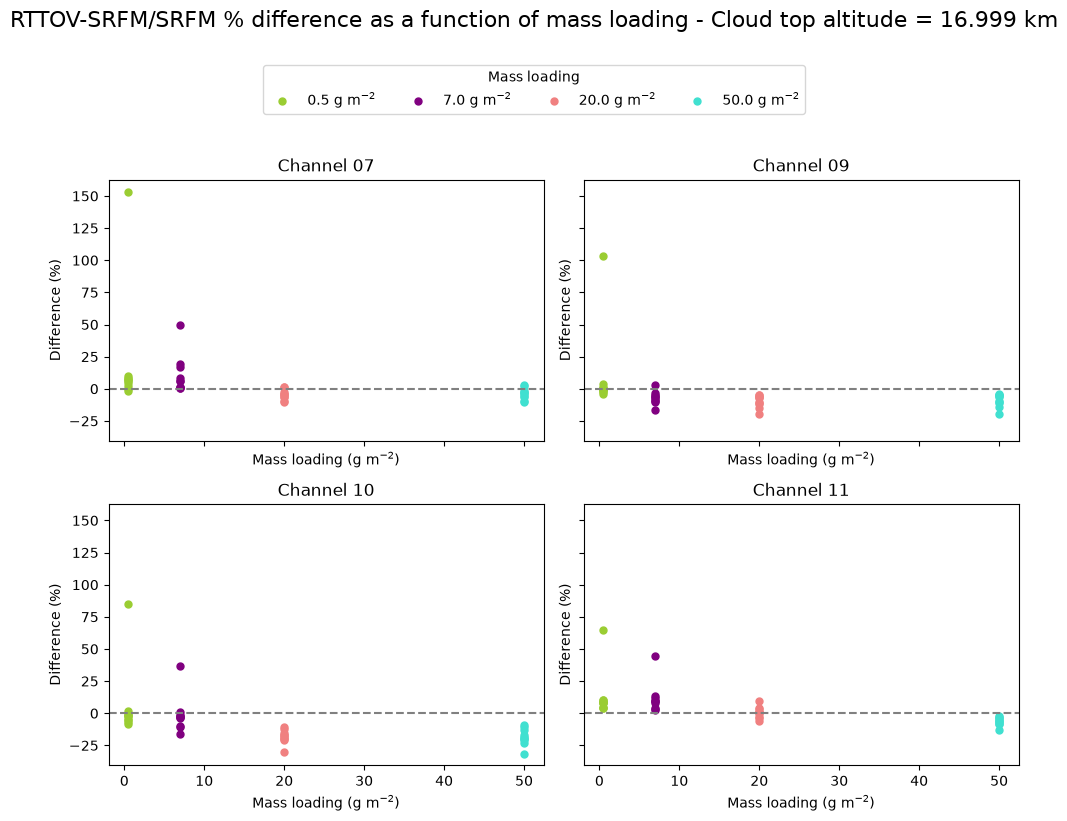

In [73]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    sharex=True,
    sharey=True
)
axes = axes.ravel()

channels = [7, 9, 10, 11]

alt_upp = 16.999
mass_colors = {
    0.5: "yellowgreen",
    7.0: "purple",
    20.0: "lightcoral",
    50.0: "turquoise",
}

# Explicit order
mass_loadings = [0.5, 7.0, 20.0, 50.0]


for ax, ch in zip(axes, channels):

    # Loop over profiles
    for profile in range(10):

        Data = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"

        df = pd.read_csv(Data)

        # Keep only the selected cloud-top altitude
        df = df[np.isclose(df["alt_upp"], alt_upp)]

        # Check available mass loadings
        if profile == 0:
            print(
                f"Profile {profile}, "
                f"Channel {ch}, "
                f"mass loadings = {sorted(df['mass_loading'].unique())}"
            )

        # Explicitly loop in desired order
        for ml in mass_loadings:

            group = df[df["mass_loading"] == ml]

            if group.empty:
                continue

            srfm = group[f"ch{ch:02d}"]
            rttov = group[f"RTTOV_ch{ch:02d}"] * 1e-3

            fraction = (rttov - srfm) / srfm * 100

     
            ax.scatter(
                group["mass_loading"],
                fraction,
                color=mass_colors[ml],
                s=25,
                label=f"{ml} g m$^{{-2}}$"
                if profile == 0 else None,
            )

    ax.axhline(
        0,
        color="gray",
        linestyle="--"
    )

    ax.set_title(f"Channel {ch:02d}")
    ax.set_xlabel("Mass loading (g m$^{-2}$)")
    ax.set_ylabel("Difference (%)")
    
fig.suptitle(
    "RTTOV-SRFM/SRFM % difference as a function of mass loading - Cloud top altitude = 16.999 km",
    fontsize=16,
    y=1.02
)

# One legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Mass loading",
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.96)
)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()



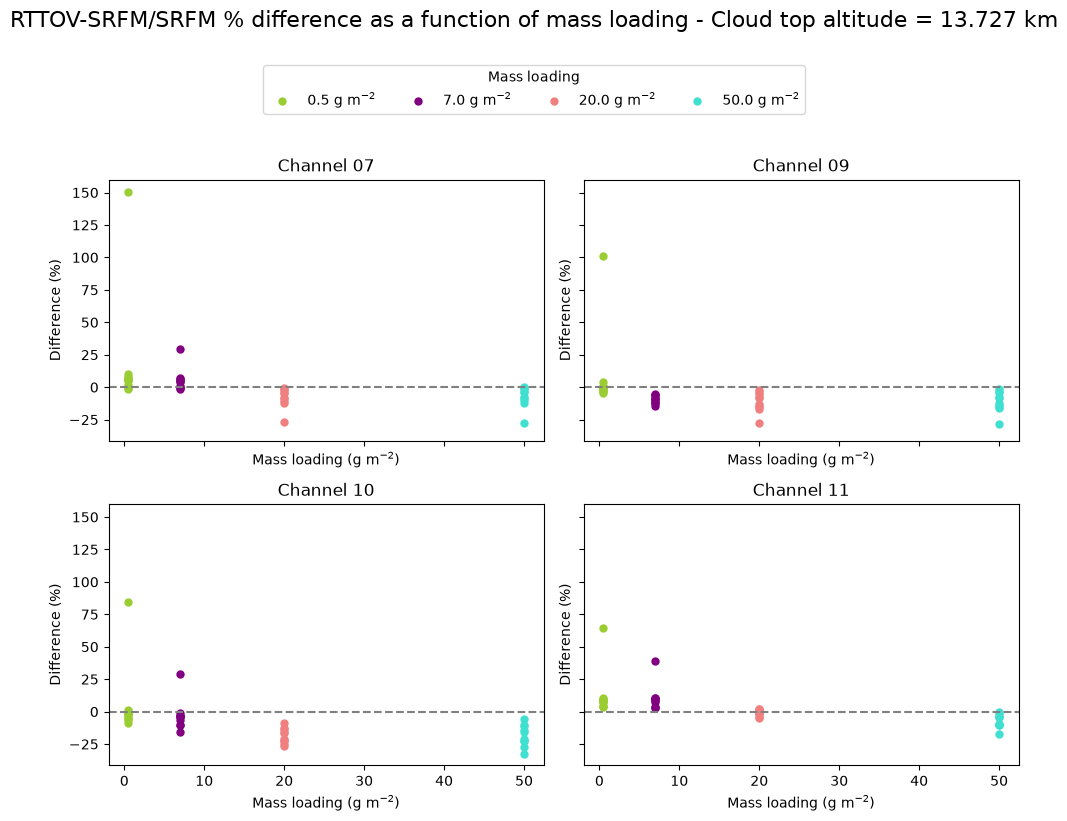

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()

channels = [7, 9, 10, 11]

alt_upp = 13.727
mass_colors = {
    0.5: "yellowgreen",
    7.0: "purple",
    20.0: "lightcoral",
    50.0: "turquoise",
}

for ax, ch in zip(axes, channels):

    for profile in range(10):

        Data = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"


        df = pd.read_csv(Data)

        # Keep only the selected cloud-top altitude
        df = df[np.isclose(df["alt_upp"], alt_upp)]

        for ml, group in df.groupby("mass_loading"):

            srfm = group[f"ch{ch:02d}"]
            rttov = group[f"RTTOV_ch{ch:02d}"] * 1e-3
            fraction = (rttov - srfm) / srfm * 100

            ax.scatter(
                group["mass_loading"],
                fraction,
                color=mass_colors[ml],
                s=25,
                label=f"{ml} g m$^{{-2}}$" if profile == 0 else None,
            )

    ax.axhline(0, color="gray", linestyle="--")
    ax.set_title(f"Channel {ch:02d}")
    ax.set_xlabel("Mass loading (g m$^{-2}$)")
    ax.set_ylabel("Difference (%)")


    
fig.suptitle(
    "RTTOV-SRFM/SRFM % difference as a function of mass loading - Cloud top altitude = 13.727 km",
    fontsize=16,
    y=1.02
)

# One legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Mass loading",
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.96)
)




plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig("/home/m/moulin-garrigues/SRFM_RTTOV/Report_Figures/ash_ml_only_13.727.png")
plt.show()

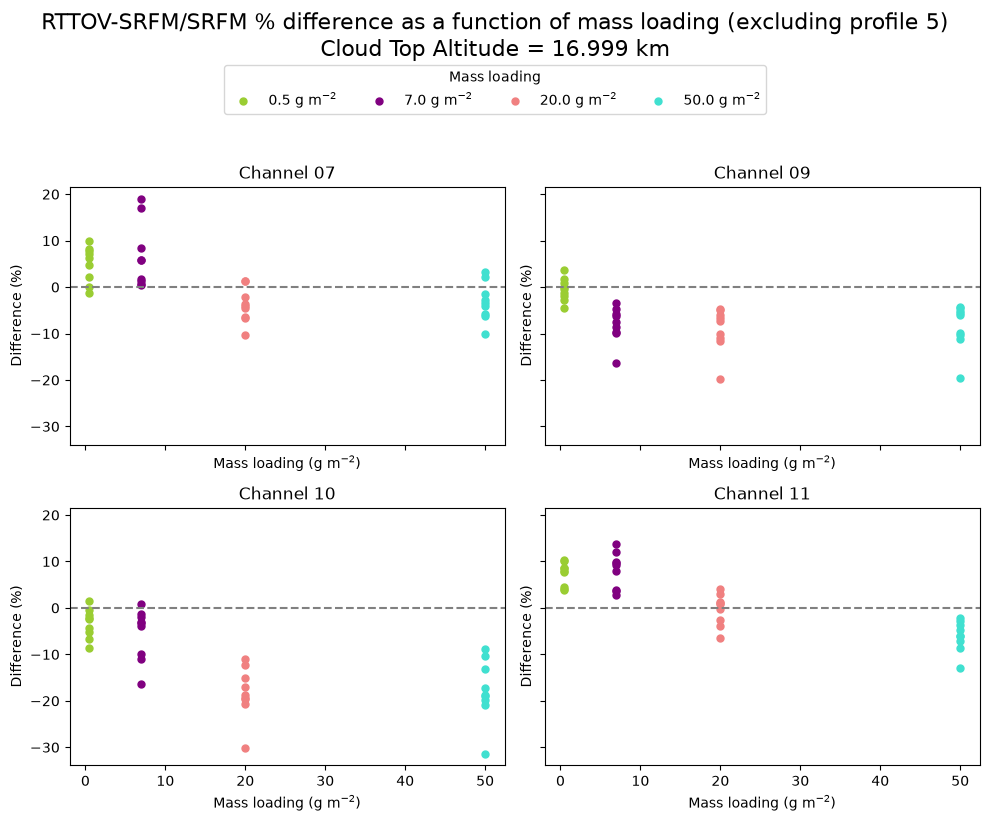

In [79]:
#Without Profile 5
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()

channels = [7, 9, 10, 11]

alt_upp = 16.999
mass_colors = {
    0.5: "yellowgreen",
    7.0: "purple",
    20.0: "lightcoral",
    50.0: "turquoise",
}

for ax, ch in zip(axes, channels):

    for profile in range(10):
        if profile == 5:
            continue

        Data = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"


        df = pd.read_csv(Data)

        # Keep only the selected cloud-top altitude
        df = df[np.isclose(df["alt_upp"], alt_upp)]

        for ml, group in df.groupby("mass_loading"):

            srfm = group[f"ch{ch:02d}"]
            rttov = group[f"RTTOV_ch{ch:02d}"] * 1e-3
            fraction = (rttov - srfm) / srfm * 100

            ax.scatter(
                group["mass_loading"],
                fraction,
                color=mass_colors[ml],
                s=25,
                label=f"{ml} g m$^{{-2}}$" if profile == 0 else None,
            )

    ax.axhline(0, color="gray", linestyle="--")
    ax.set_title(f"Channel {ch:02d}")
    ax.set_xlabel("Mass loading (g m$^{-2}$)")
    ax.set_ylabel("Difference (%)")
    
fig.suptitle(
    "RTTOV-SRFM/SRFM % difference as a function of mass loading (excluding profile 5)\n"
    "Cloud Top Altitude = 16.999 km",
    fontsize=16,
    y=1.02
)

# One legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Mass loading",
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.96)
)


plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("/home/m/moulin-garrigues/SRFM_RTTOV/Report_Figures/ash_ml_only_13.727.png")
plt.show()

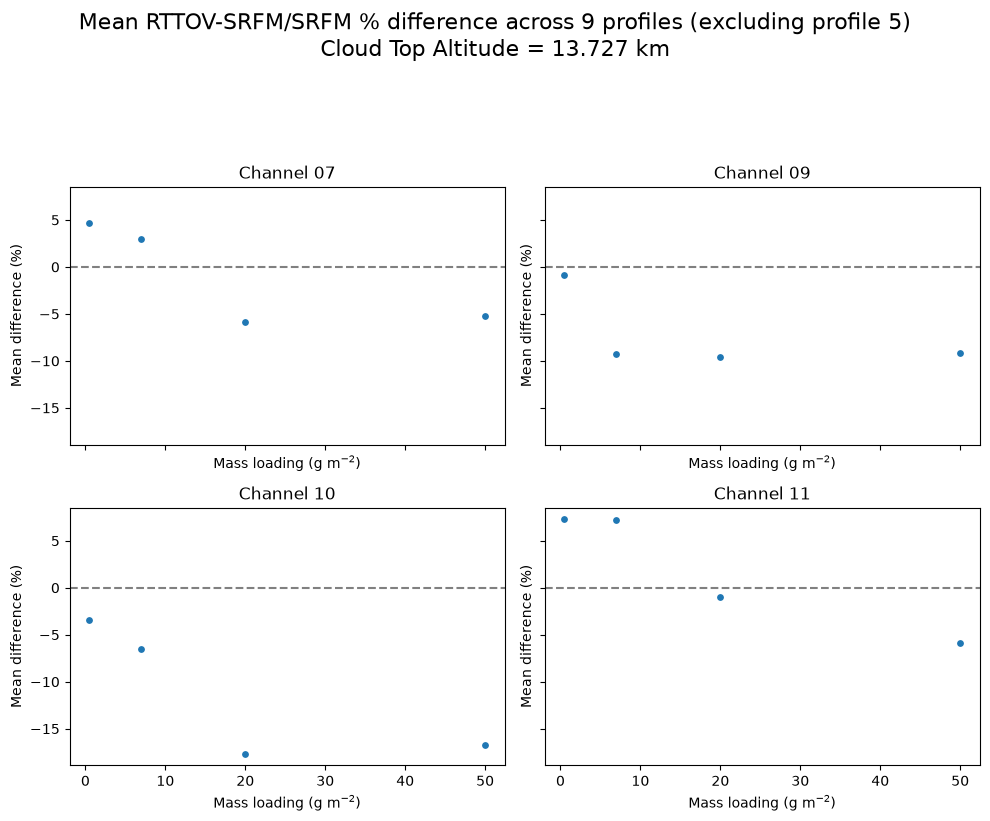

In [65]:


##can I have your attention please
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()

channels = [7, 9, 10, 11]
alt_upp = 13.727

mass_loadings = [0.5, 7.0, 20.0, 50.0]

for ax, ch in zip(axes, channels):

    # Store the mean difference for each profile and mass loading
    profile_means = {ml: [] for ml in mass_loadings}

    for profile in range(10):

        if profile == 5:
            continue

        Data = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"

        df = pd.read_csv(Data)
        df = df[np.isclose(df["alt_upp"], alt_upp)]

        for ml in mass_loadings:

            group = df[df["mass_loading"] == ml]

            srfm = group[f"ch{ch:02d}"]
            rttov = group[f"RTTOV_ch{ch:02d}"] * 1e-3

            fraction = (rttov - srfm) / srfm * 100

            # Mean difference for this profile and mass loading
            profile_means[ml].append(fraction.mean())

    # Mean across the 9 profiles
    mean_difference = {
        ml: np.mean(profile_means[ml])
        for ml in mass_loadings
    }

    # Plot mean difference against mass loading
    ax.scatter(
        mass_loadings,
        [mean_difference[ml] for ml in mass_loadings], s= 15
    )

    ax.axhline(0, color="gray", linestyle="--")

    ax.set_title(f"Channel {ch:02d}")
    ax.set_xlabel("Mass loading (g m$^{-2}$)")
    ax.set_ylabel("Mean difference (%)")


fig.suptitle(
    "Mean RTTOV-SRFM/SRFM % difference across 9 profiles (excluding profile 5)\n"
    "Cloud Top Altitude = 13.727 km",
    fontsize=16,
    y=1.02
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig(
    "/home/m/moulin-garrigues/SRFM_RTTOV/Report_Figures/"
    "mean_difference_ml_13.727_without_profile5.png"
)

plt.show()

##excuse me



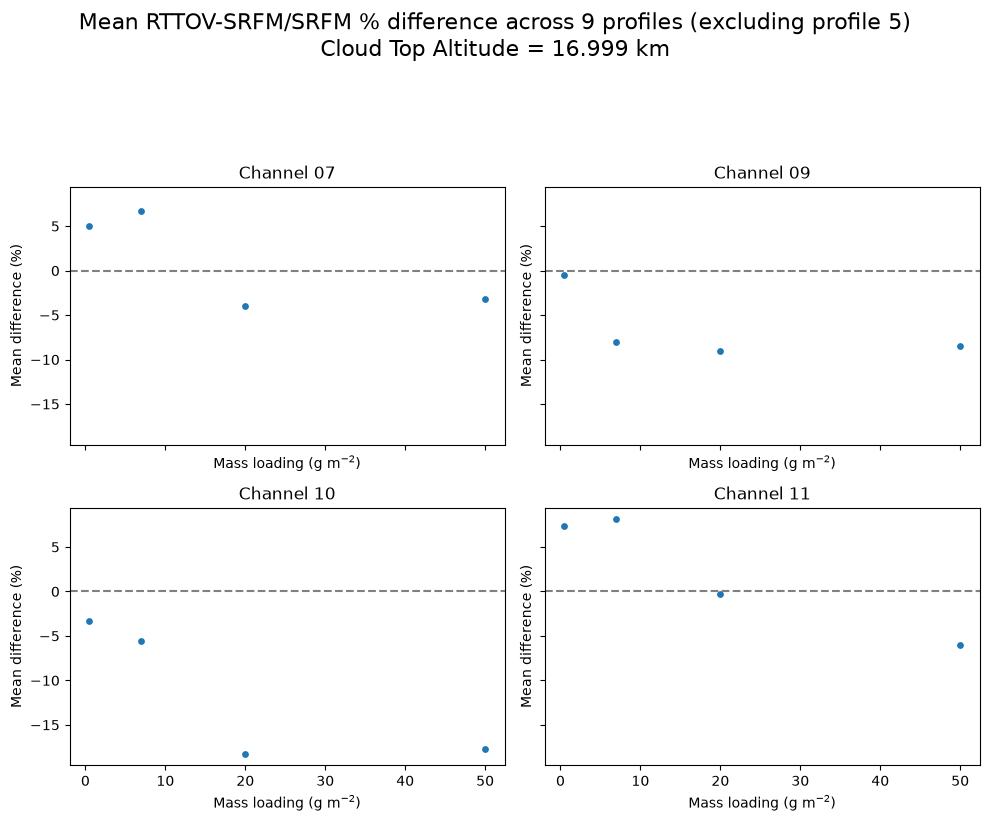

In [67]:


fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()

channels = [7, 9, 10, 11]
alt_upp = 16.999
mass_loadings = [0.5, 7.0, 20.0, 50.0]

for ax, ch in zip(axes, channels):

    # Store the mean difference for each profile and mass loading
    profile_means = {ml: [] for ml in mass_loadings}

    for profile in range(10):

        if profile == 5:
            continue

        Data = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"

        df = pd.read_csv(Data)
        df = df[np.isclose(df["alt_upp"], alt_upp)]

        for ml in mass_loadings:

            group = df[df["mass_loading"] == ml]

            srfm = group[f"ch{ch:02d}"]
            rttov = group[f"RTTOV_ch{ch:02d}"] * 1e-3

            fraction = (rttov - srfm) / srfm * 100

            # Mean difference for this profile and mass loading
            profile_means[ml].append(fraction.mean())

    # Mean across the 9 profiles
    mean_difference = {
        ml: np.mean(profile_means[ml])
        for ml in mass_loadings
    }

    # Plot mean difference against mass loading
    ax.scatter(
        mass_loadings,
        [mean_difference[ml] for ml in mass_loadings], s= 15
    )

    ax.axhline(0, color="gray", linestyle="--")

    ax.set_title(f"Channel {ch:02d}")
    ax.set_xlabel("Mass loading (g m$^{-2}$)")
    ax.set_ylabel("Mean difference (%)")


fig.suptitle(
    "Mean RTTOV-SRFM/SRFM % difference across 9 profiles (excluding profile 5)\n"
    "Cloud Top Altitude = 16.999 km",
    fontsize=16,
    y=1.02
)

plt.tight_layout(rect=[0, 0, 1, 0.93])

plt.savefig(
    "/home/m/moulin-garrigues/SRFM_RTTOV/Report_Figures/"
    "mean_difference_ml_13.727_without_profile5.png"
)

plt.show()




## Altitudes Comparison

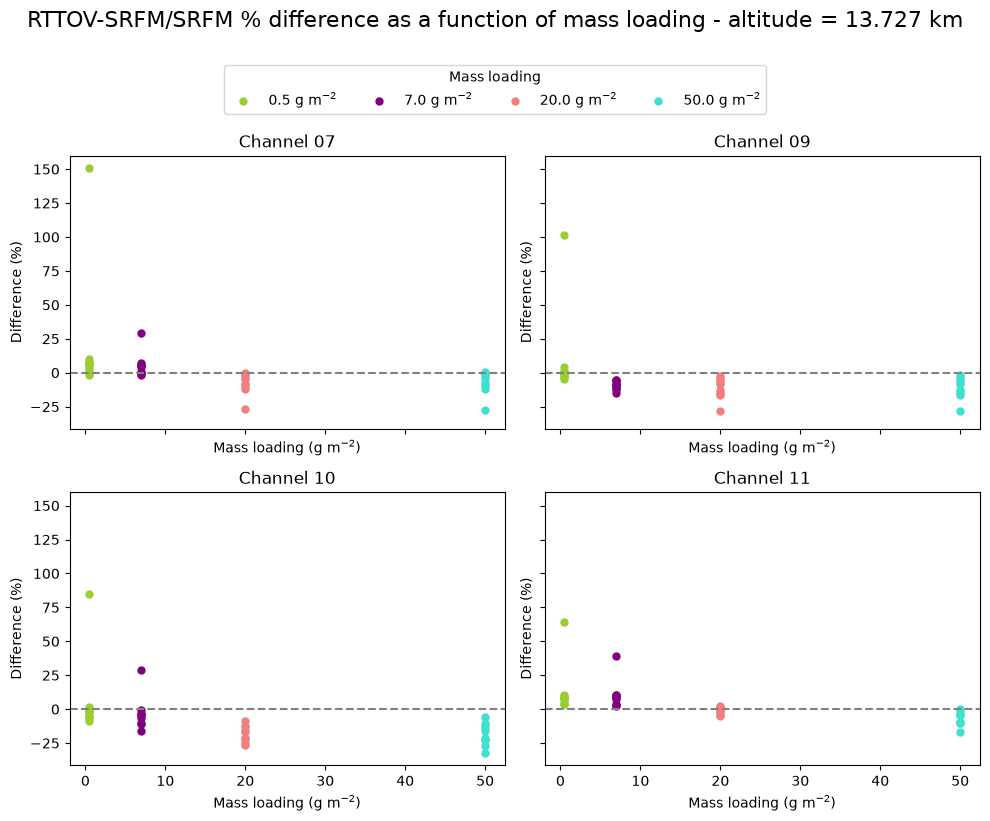

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.ravel()

channels = [7, 9, 10, 11]

alt_upp = 13.727
altitudes = {
    16.999: "yellowgreen",
    13,: "purple",
    20.0: "lightcoral",
    50.0: "turquoise",
}

for ax, ch in zip(axes, channels):

    for profile in range(10):

        Data = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"


        df = pd.read_csv(Data)

        # Keep only the selected cloud-top altitude
        df = df[np.isclose(df["alt_upp"], alt_upp)]

        for ml, group in df.groupby("mass_loading"):

            srfm = group[f"ch{ch:02d}"]
            rttov = group[f"RTTOV_ch{ch:02d}"] * 1e-3
            fraction = (rttov - srfm) / srfm * 100

            ax.scatter(
                group["mass_loading"],
                fraction,
                color=mass_colors[ml],
                s=25,
                label=f"{ml} g m$^{{-2}}$" if profile == 0 else None,
            )

    ax.axhline(0, color="gray", linestyle="--")
    ax.set_title(f"Channel {ch:02d}")
    ax.set_xlabel("Mass loading (g m$^{-2}$)")
    ax.set_ylabel("Difference (%)")


    
fig.suptitle(
    "RTTOV-SRFM/SRFM % difference as a function of mass loading - altitude = 13.727 km",
    fontsize=16,
    y=1.02
)

# One legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Mass loading",
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.96)
)




plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("/home/m/moulin-garrigues/SRFM_RTTOV/Report_Figures/ash_ml_only_13.727.png")
plt.show()

## Clear Sky Correction

Statistics

Channel 07
  Number of points = 80
  Mean Bias        = 0.001294
  RMSE             = 0.005234
  Standard Deviation = 0.005071

Channel 09
  Number of points = 80
  Mean Bias        = -0.000158
  RMSE             = 0.006823
  Standard Deviation = 0.006821

Channel 10
  Number of points = 80
  Mean Bias        = -0.001845
  RMSE             = 0.008573
  Standard Deviation = 0.008372

Channel 11
  Number of points = 80
  Mean Bias        = 0.002779
  RMSE             = 0.006809
  Standard Deviation = 0.006216


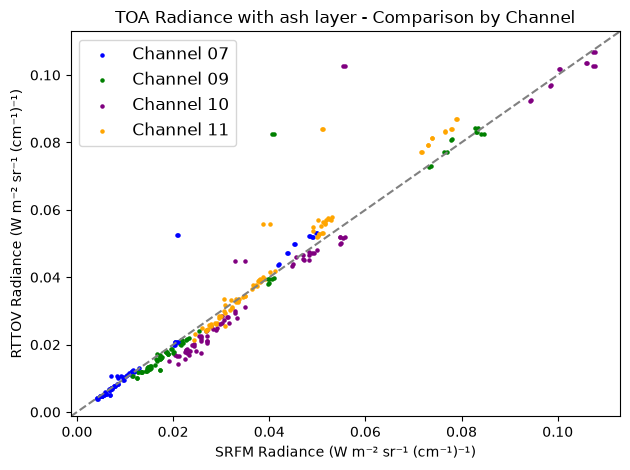

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

channels = [7, 9, 10, 11]

colors = {
    7: "blue",
    9: "green",
    10: "purple",
    11: "orange"
}

# Store differences separately for each channel
all_diff = {ch: [] for ch in channels}


for profile in range(10):

    Data = (
        f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/"
        f"Merge_Ash_nobias/Merge_{profile}_nobias_numdem23.csv"
    )

    df = pd.read_csv(Data)

    for ch in channels:

        # -----------------------------
        # Get the data for this channel
        # -----------------------------
        srfm = df[f"ch{ch:02d}"]
        rttov = df[f"RTTOV_ch{ch:02d}"] * 1e-3

        # -----------------------------
        # Scatter plot
        # -----------------------------
        ax.scatter(
            srfm,
            rttov,
            color=colors[ch],
            s=5,
            label=f"Channel {ch:02d}" if profile == 0 else None,
        )

        # -----------------------------
        # Difference RTTOV - SRFM
        # -----------------------------
        diff = (rttov - srfm).dropna().values

        # Store differences for THIS channel
        all_diff[ch].extend(diff)


# ============================================================
# 1:1 LINE
# ============================================================

lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1])
]

ax.plot(
    lims,
    lims,
    color="gray",
    linestyle="--"
)

ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("SRFM Radiance (W m⁻² sr⁻¹ (cm⁻¹)⁻¹)")
ax.set_ylabel("RTTOV Radiance (W m⁻² sr⁻¹ (cm⁻¹)⁻¹)")

ax.set_title(
    "TOA Radiance with ash layer - Comparison by Channel"
)

ax.legend(fontsize=12)

plt.tight_layout()

plt.savefig(
    "/home/m/moulin-garrigues/SRFM_RTTOV/Report_Figures/ash_channel.png",
    dpi=300
)


# ============================================================
# STATISTICS
# ============================================================

print("Statistics")
print("=" * 60)

for ch in channels:

    diff = np.asarray(all_diff[ch])

    mean_bias = np.mean(diff)
    rmse = np.sqrt(np.mean(diff ** 2))
    stdev = np.std(diff)

    print(f"\nChannel {ch:02d}")
    print(f"  Number of points = {len(diff)}")
    print(f"  Mean Bias        = {mean_bias:.6f}")
    print(f"  RMSE             = {rmse:.6f}")
    print(f"  Standard Deviation = {stdev:.6f}")


plt.show()


## Looking at RTTOV only data

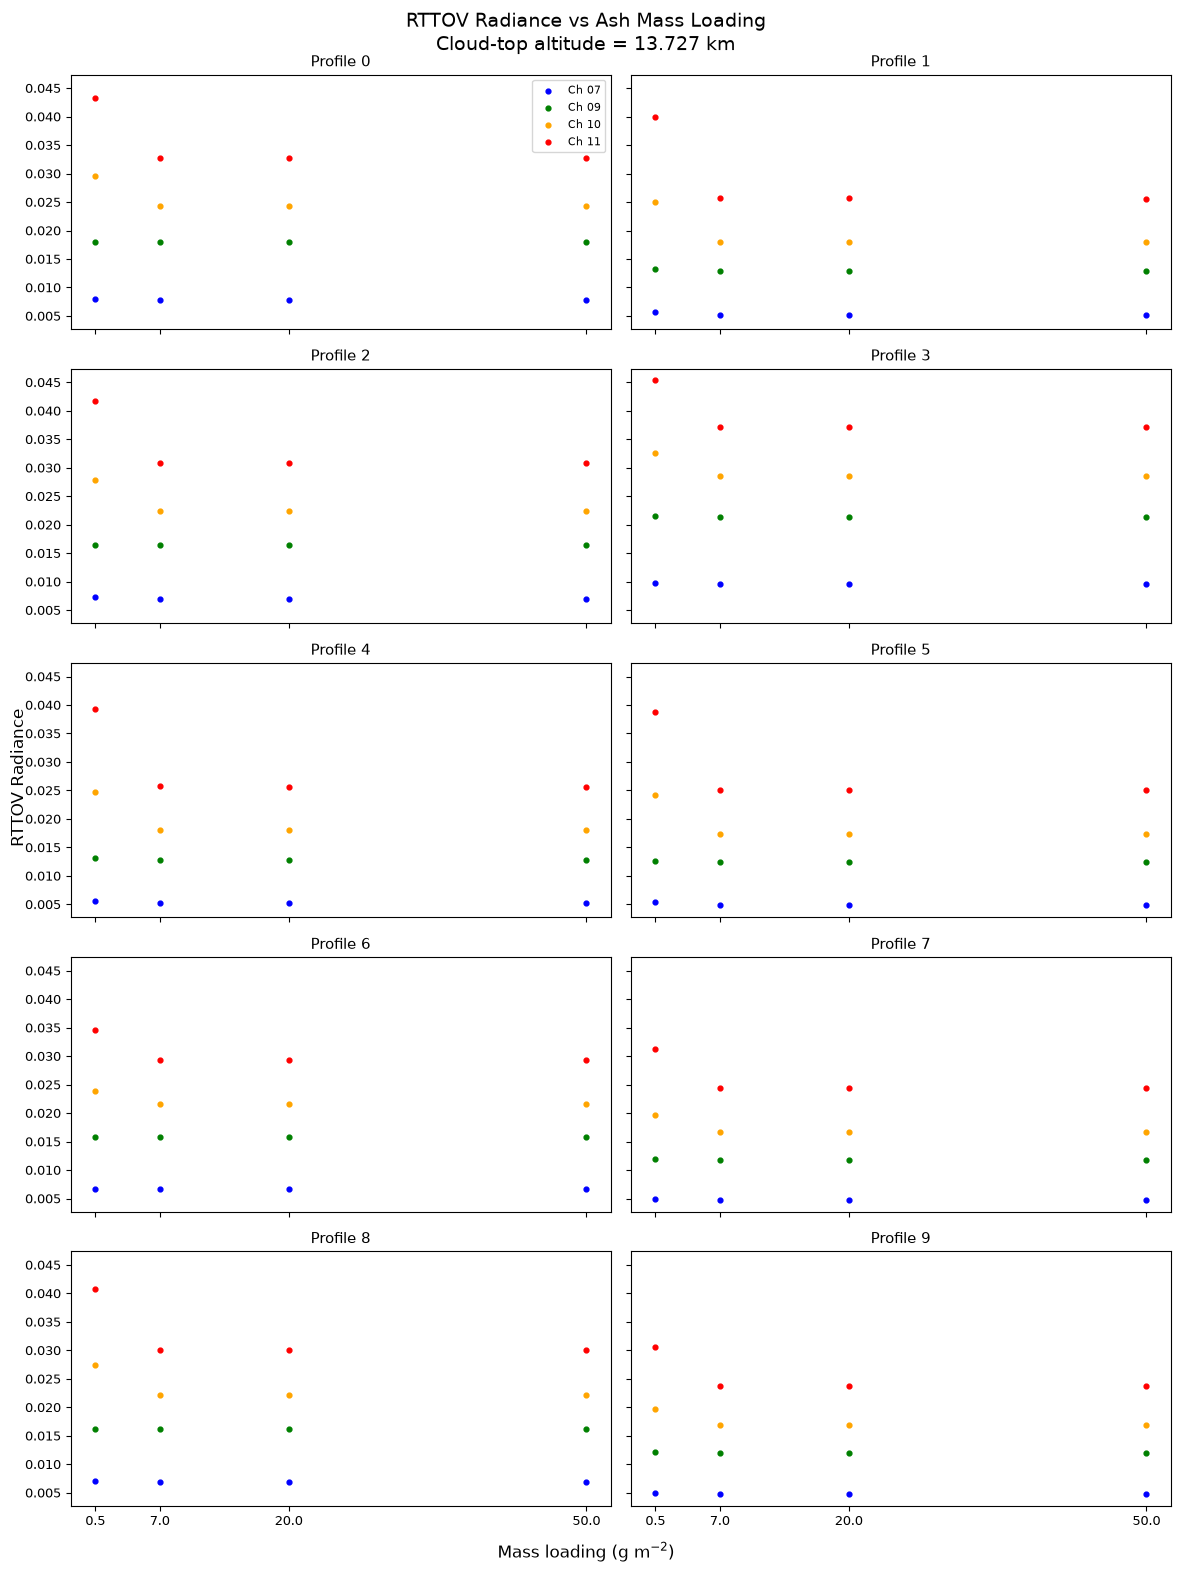

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

channels = [7, 9, 10, 11]

alt_upp = 13.727

ch_colors = {
    7: "blue",
    9: "green",
    10: "orange",
    11: "red",
}

fig, axes = plt.subplots(
    5, 2,
    figsize=(12, 16),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for profile in range(10):

    Data = (
        f"/home/m/moulin-garrigues/RTTOV/Full_Rad_7_08/"
        f"Merge_Ash_numdem/Merge_{profile}_numdem.csv"
    )

    df = pd.read_csv(Data)

    # Select cloud-top altitude
    df = df[np.isclose(df["alt_upp"], alt_upp)]

    ax = axes[profile]

    for ch in channels:

        rttov = df[f"RTTOV_ch{ch:02d}"] * 1e-3

        ax.scatter(
            df["mass_loading"],
            rttov,
            color=ch_colors[ch],
            s=12,
            label=f"Ch {ch:02d}"
        )

    ax.set_title(f"Profile {profile}", fontsize=11)

    ax.set_xticks([0.5, 7, 20, 50])
    ax.tick_params(axis="both", labelsize=9)

    # Legend only on first plot
    if profile == 0:
        ax.legend(fontsize=8)

fig.supxlabel("Mass loading (g m$^{-2}$)", fontsize=12)
fig.supylabel("RTTOV Radiance", fontsize=12)

fig.suptitle(
    f"RTTOV Radiance vs Ash Mass Loading\n"
    f"Cloud-top altitude = {alt_upp} km",
    fontsize=14
)

plt.tight_layout()
plt.show()

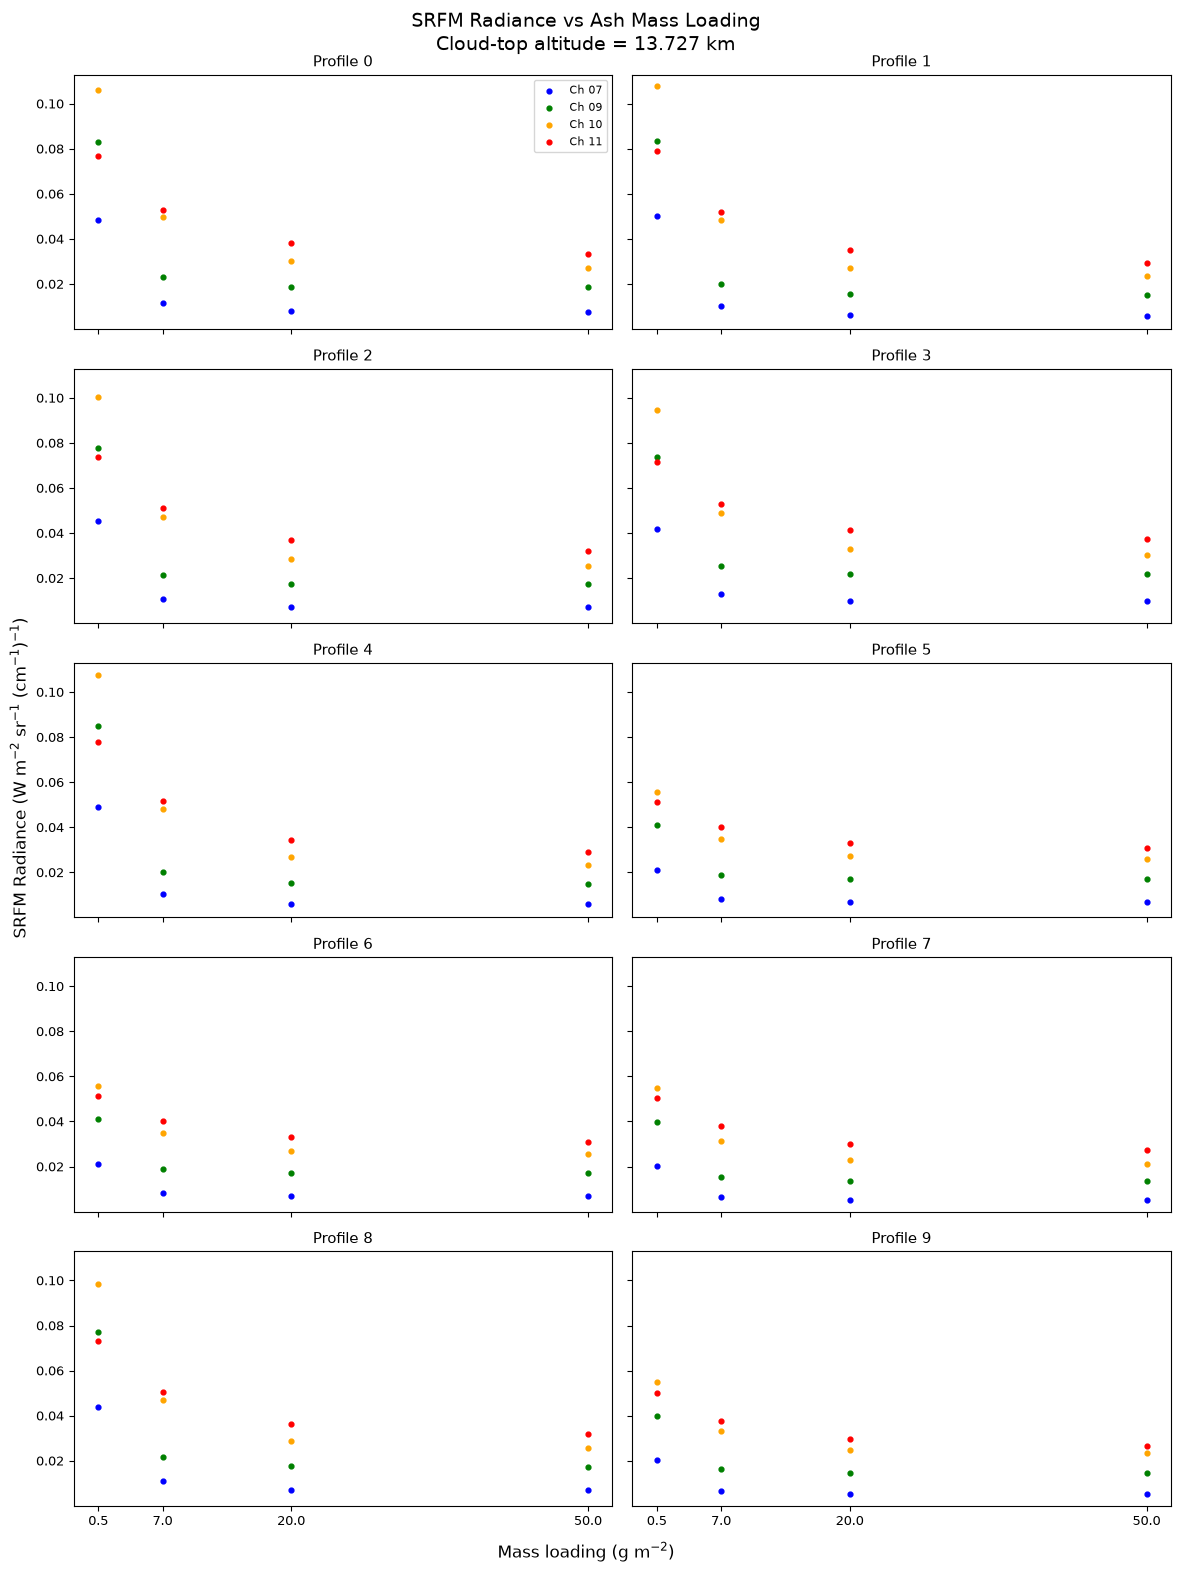

In [44]:
##looking at SRFM only radiance vs mass loading
import numpy as np
import pandas as pd
import matplotlib

matplotlib.use("pdf")

import matplotlib.pyplot as plt


channels = [7, 9, 10, 11]

alt_upp = 13.727

ch_colors = {
    7: "blue",
    9: "green",
    10: "orange",
    11: "red",
}

fig, axes = plt.subplots(
    5, 2,
    figsize=(12, 16),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for profile in range(10):

    Data = (
        f"/home/m/moulin-garrigues/RTTOV/Full_Rad_7_08/"
        f"Merge_Ash_numdem/Merge_{profile}_numdem.csv"
    )

    df = pd.read_csv(Data)

    # Select cloud-top altitude
    df = df[np.isclose(df["alt_upp"], alt_upp)]

    ax = axes[profile]

    for ch in channels:

        srfm = df[f"ch{ch:02d}"] 

        ax.scatter(
            df["mass_loading"],
            srfm,
            color=ch_colors[ch],
            s=12,
            label=f"Ch {ch:02d}"
        )

    ax.set_title(f"Profile {profile}", fontsize=11)

    ax.set_xticks([0.5, 7, 20, 50])
    ax.tick_params(axis="both", labelsize=9)


    # Legend only on first plot
    if profile == 0:
        ax.legend(fontsize=8)

fig.supxlabel("Mass loading (g m$^{-2}$)", fontsize=12)
fig.supylabel("SRFM Radiance (W m$^{-2}$ sr$^{-1}$ (cm$^{-1}$)$^{-1}$)", fontsize=12)

fig.suptitle(
    f"SRFM Radiance vs Ash Mass Loading\n"
    f"Cloud-top altitude = {alt_upp} km",
    fontsize=14
)

plt.tight_layout()
plt.show()

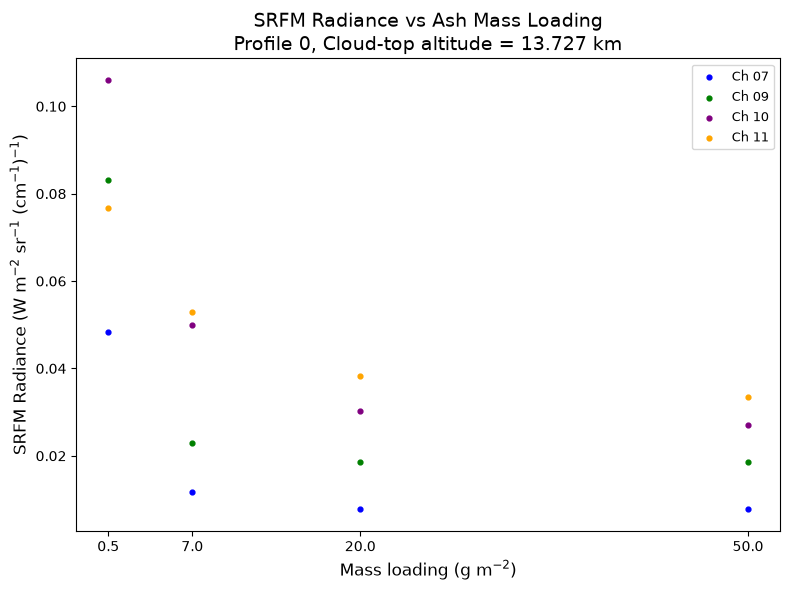

In [11]:
# SRFM radiance vs mass loading — Profile 0

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

channels = [7, 9, 10, 11]

alt_upp = 13.727
profile = 0

colors = {
    7: "blue",
    9: "green",
    10: "purple",
    11: "orange"
}
Data = (
    f"/home/m/moulin-garrigues/RTTOV/Full_Rad_7_08/"
    f"Merge_Ash_numdem/Merge_{profile}_numdem.csv"
)

df = pd.read_csv(Data)

# Select cloud-top altitude
df = df[np.isclose(df["alt_upp"], alt_upp)]

# Create one plot
fig, ax = plt.subplots(figsize=(8, 6))

for ch in channels:

    srfm = df[f"ch{ch:02d}"]

    ax.scatter(
        df["mass_loading"],
        srfm,
        color=colors[ch],
        s=12,
        label=f"Ch {ch:02d}"
    )

ax.set_title(
    f"SRFM Radiance vs Ash Mass Loading\n"
    f"Profile {profile}, Cloud-top altitude = {alt_upp} km",
    fontsize=14
)

ax.set_xticks([0.5, 7, 20, 50])

ax.set_xlabel(
    "Mass loading (g m$^{-2}$)",
    fontsize=12
)

ax.set_ylabel(
    "SRFM Radiance (W m$^{-2}$ sr$^{-1}$ (cm$^{-1}$)$^{-1}$)",
    fontsize=12
)

ax.tick_params(axis="both", labelsize=10)

ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("/home/m/moulin-garrigues/SRFM_RTTOV/Report_Figures/ash_ml_only_13.727_SRFm.png")

plt.show()


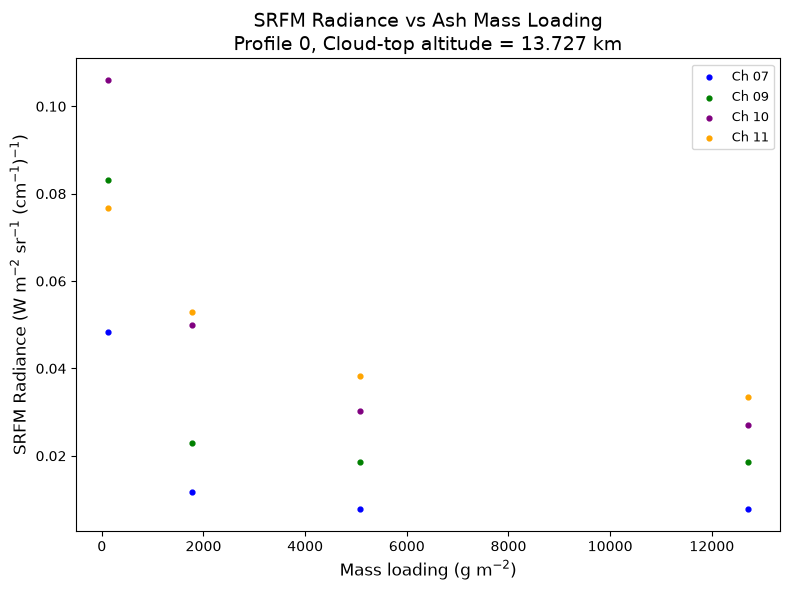

In [7]:
# SRFM radiance vs mass loading — Profile 0

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

channels = [7, 9, 10, 11]

alt_upp = 13.727
profile = 0

colors = {
    7: "blue",
    9: "green",
    10: "purple",
    11: "orange"
}
num = [127.117,1779.635,5084.672,12711.680]
Data = (
    f"/home/m/moulin-garrigues/RTTOV/Full_Rad_7_08/"
    f"Merge_Ash_numdem/Merge_{profile}_numdem.csv"
)

df = pd.read_csv(Data)

# Select cloud-top altitude
df = df[np.isclose(df["alt_upp"], alt_upp)]

# Create one plot
fig, ax = plt.subplots(figsize=(8, 6))

for ch in channels:

    srfm = df[f"ch{ch:02d}"]

    ax.scatter(
        num,
        srfm,
        color=colors[ch],
        s=12,
        label=f"Ch {ch:02d}"
    )

ax.set_title(
    f"SRFM Radiance vs Ash Mass Loading\n"
    f"Profile {profile}, Cloud-top altitude = {alt_upp} km",
    fontsize=14
)


ax.set_xlabel(
    "Mass loading (g m$^{-2}$)",
    fontsize=12
)

ax.set_ylabel(
    "SRFM Radiance (W m$^{-2}$ sr$^{-1}$ (cm$^{-1}$)$^{-1}$)",
    fontsize=12
)

ax.tick_params(axis="both", labelsize=10)

ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("/home/m/moulin-garrigues/SRFM_RTTOV/Report_Figures/ash_ml_only_13.727_SRFm.png")

plt.show()


## Extra

In [ ]:
mass_loading = 20.0
alt_upp = 16.999

for profile in range(10):

    Data = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_7_08/Merge_Ash_numdem/Merge_{profile}_numdem.csv"
    df = pd.read_csv(Data)

    # Select only the desired simulation
    mask = (
        np.isclose(df["mass_loading"], mass_loading) &
        np.isclose(df["alt_upp"], alt_upp)
    )

    df = df.loc[mask]

    srfm = df[f"ch{ch:02d}"]
    rttov = df[f"RTTOV_ch{ch:02d}"] * 1e-3
    fraction = (rttov - srfm) / srfm * 100

    ax.scatter(
        srfm,
        fraction,
        color=profile_colors[profile],   # different color for each profile
        s=20,
        label=f"Profile {profile}",
    )